# Perfilamiento de consumidores de drogas mediante Clustering

Brayan David Trujillo Perdomo

## ¿De qué trata este proyecto?

* El consumo de sustancias psicoactivas es un fenómeno complejo que no afecta a todos por igual. El objetivo de este proyecto es identificar y caracterizar los diferentes perfiles de consumidores dentro de una población de personas encuestadas sobre su consumo de drogas haciendo uso de aprendizaje no supervisado.

* Este perfilamiento permite ir más allá de la simple estadística descriptiva. Al entender qué rasgos de personalidad y entornos sociales se asocian a patrones de consumo específicos (ya sea recreativo, esporádico o de alto riesgo), se pueden diseñar estrategias de prevención, salud pública e intervención clínica mucho más precisas, personalizadas y eficientes.




https://www.kaggle.com/datasets/obeykhadija/drug-consumptions-uci?select=Drug_Consumption.csv

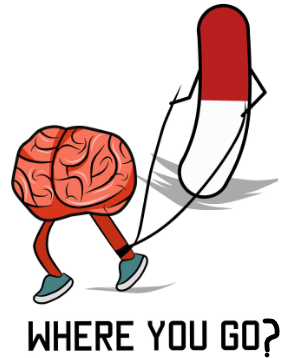

---

## Justificación

La idea es descubrir si existen **perfiles diferenciados de consumidores** basándonos en sus características de personalidad y sus patrones de consumo, sin que nadie le haya dicho al algoritmo cuántos grupos hay ni cómo son.

---

## Pregunta de investigación

> **¿Existen perfiles diferenciados de consumidores según sus rasgos de personalidad y sus patrones de consumo de sustancias?**

Esta pregunta puede ser útil porque:
- No existe una "etiqueta" oficial de tipo de consumidor.
- Si logramos identificar grupos, se podrían diseñar estrategias de intervención o prevención más personalizadas.
- Es un problema típico de segmentación sin supervisión.

---

## Estructura del notebook

1. **Sección 1** — Problema y datos
2. **Sección 2** — Modelado: K-Means vs. Clustering Jerárquico
3. **Sección 3** — Interpretación y visualizaciones
4. **Sección 4** — Conclusiones
5. **Sección 5** — Uso de IA

---
# Sección 1 — Problema y Datos

## 1.1 Preparación del entorno - Librerías

In [1]:
# Librerías generales
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Estilo de los gráficos
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

## 1.2 Carga del dataset

In [2]:
df = pd.read_excel('drug_consumption.xlsx', sheet_name='Dataset')
print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print()
print("Primeras filas:")
df.head()

Dimensiones del dataset: 1885 filas × 32 columnas

Primeras filas:


,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,35-44,Female,Professional Certificate/Diploma,UK,Mixed-White/Asian,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,25-34,Male,Doctorate Degree,UK,White,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,35-44,Male,Professional Certificate/Diploma,UK,White,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,18-24,Female,Masters Degree,UK,White,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,35-44,Female,Doctorate Degree,UK,White,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


* Se cuestionó a los participantes sobre su uso de 18 drogas legales e ilegales entre las que hay **depresores, estimulantes y alucinógenos**.

* Además, una droga ficticia (Semer) que se introdujo para identificar a quienes exageran o falsean respuestas.

* Para cada droga, debían seleccionar una de las respuestas: nunca usó la droga, la usó hace más de una década, o en la última década, año, mes, semana o día.

## 1.3 Exploración básica

**Variables del dataset:**
- **Demográficas:** Age, Gender, Education, Country, Ethnicity.
- **Personalidad (Big Five + extras):** Inestabilidad emocional (neuroticismo), extraversión o sociabilidad, apertura a la experiencia, amabilidad, responsabilidad, impulsividad, búsqueda de sensaciones.
- **Consumo de sustancias:** Alcohol, Cannabis, Coke, etc. (en categorías CL0 a CL6).

In [3]:
# Tipos de variables y valores faltantes
print("=== Tipos de variables ===")
print(df.dtypes)
print()
print(f"=== Valores faltantes totales: {df.isnull().sum().sum()} ===")

=== Tipos de variables ===
ID             int64
Age           object
Gender        object
Education     object
Country       object
Ethnicity     object
Nscore       float64
Escore       float64
Oscore       float64
Ascore       float64
Cscore       float64
Impulsive    float64
SS           float64
Alcohol       object
Amphet        object
Amyl          object
Benzos        object
Caff          object
Cannabis      object
Choc          object
Coke          object
Crack         object
Ecstasy       object
Heroin        object
Ketamine      object
Legalh        object
LSD           object
Meth          object
Mushrooms     object
Nicotine      object
Semer         object
VSA           object
dtype: object

=== Valores faltantes totales: 0 ===


## 1.4 Análisis exploratorio

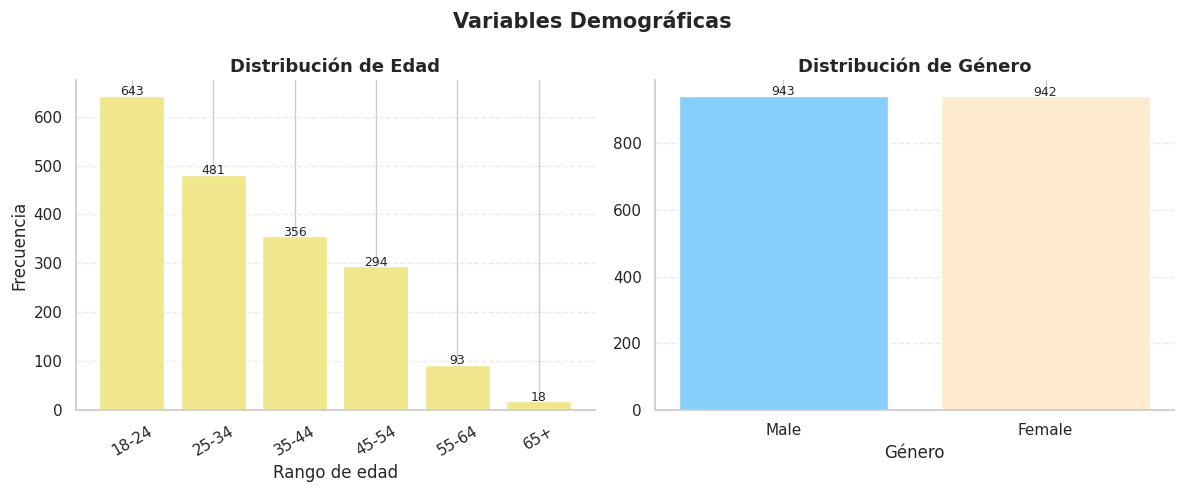

In [4]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Edad
age_counts = df['Age'].value_counts().sort_index()

bars = axes[0].bar(
    age_counts.index,
    age_counts.values,
    color="#F0E68C",
    edgecolor="white"
)

axes[0].set_title("Distribución de Edad", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Rango de edad")
axes[0].set_ylabel("Frecuencia")
axes[0].tick_params(axis='x', rotation=30)

for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        int(bar.get_height()),
        ha='center',
        fontsize=9
    )

# Género
gender_counts = df['Gender'].value_counts()

bars = axes[1].bar(
    gender_counts.index,
    gender_counts.values,
    color=["#87CEFA", "#FFEBCD"],
    edgecolor="white"
)

axes[1].set_title("Distribución de Género", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Género")

for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        int(bar.get_height()),
        ha='center',
        fontsize=9
    )

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle(
    "Variables Demográficas",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

* El rango de 18-24 años es el más predominante con 643 encuestados, seguido por el grupo de 25-34 años con 481; en contraste, la participación disminuye drásticamente a medida que avanza la edad, registrando la menor representatividad en los adultos mayores de 65 años con solo 18 individuos.

* Se presenta un equilibrio demográfico balanceado, constituido por 943 hombres (Male) y 942 mujeres (Female). Desde la perspectiva metodológica y de análisis para el estudio de sustancias psicoactivas, esta equidad es un factor de alta calidad, ya que elimina sesgos por representatividad numérica y permite comparar con mejor precisión si existen diferencias significativas de género en los hábitos de consumo, tipos de sustancias elegidas o vulnerabilidades asociadas a la adicción.

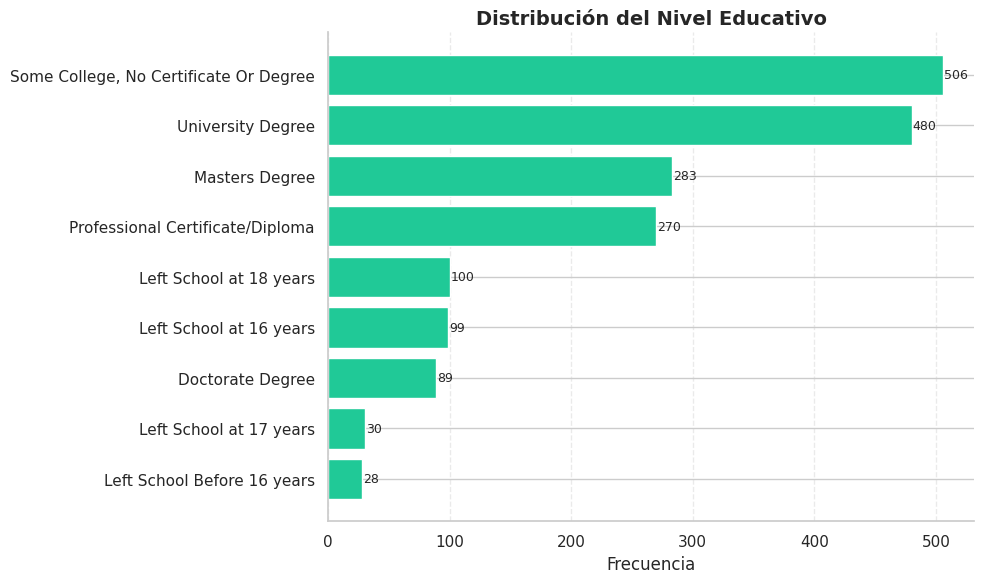

In [5]:
edu_counts = df['Education'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    edu_counts.index,
    edu_counts.values,
    color="#20C997",
    edgecolor="white"
)

ax.set_title(
    "Distribución del Nivel Educativo",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Frecuencia")
ax.set_ylabel("")

for bar in bars:
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va='center',
        fontsize=9
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

* La población encuestada posee un perfil educativo de nivel superior, donde la categoría más frecuente corresponde a personas con educación universitaria incompleta (Some College, No Certificate Or Degree) con 506 individuos, seguida de cerca por aquellos con un título universitario finalizado (University Degree) con 480.
* Por el contrario, los sectores con niveles educativos básicos o abandono escolar temprano son minoritarios, registrando la menor participación quienes dejaron la escuela antes de los 16 años con solo 28 personas. La formación académica es una variable sociodemográfica clave, ya que permite analizar cómo influyen el entorno universitario en los patrones de consumo y en la percepción del riesgo frente a las drogas.

In [6]:
# Estadísticas descriptivas de las variables de personalidad
personality_cols = ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
print("=== Estadísticas de personalidad ===")
df[personality_cols].describe().round(3)

=== Estadísticas de personalidad ===


,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS
count,1885.000,1885.000,1885.000,1885.000,1885.000,1885.000,1885.000
mean,0.000,-0.000,-0.001,-0.000,-0.000,0.007,-0.003
std,0.998,0.997,0.996,0.997,0.998,0.954,0.964
min,-3.464,-3.274,-3.274,-3.464,-3.464,-2.555,-2.078
25%,-0.678,-0.695,-0.717,-0.606,-0.653,-0.711,-0.526
50%,0.043,0.003,-0.019,-0.017,-0.007,-0.217,0.080
75%,0.630,0.638,0.723,0.761,0.585,0.530,0.765
max,3.274,3.274,2.902,3.464,3.464,2.902,1.922


## 1.5 Preprocesamiento

* Para aplicar clustering trabajamos con variables numéricas. Se realiza conversión de las variables de consumo están como texto (CL0, CL1, ..., CL6) a números del 0 al 6, donde:
- **CL0** = Nunca consumió
- **CL6** = Consumió en el último día

* Se excluye **Semer**, que es una droga ficticia incluida para detectar respuestas falsas.
* Se realiza escalamiento de variables para aplicación de clustering.

In [7]:
# Convirtiendo categorías de consumo a números
cl_map = {'CL0': 0, 'CL1': 1, 'CL2': 2, 'CL3': 3, 'CL4': 4, 'CL5': 5, 'CL6': 6}

drug_cols = ['Alcohol', 'Amphet', 'Amyl', 'Benzos', 'Caff', 'Cannabis', 'Choc',
             'Coke', 'Crack', 'Ecstasy', 'Heroin', 'Ketamine', 'Legalh',
             'LSD', 'Meth', 'Mushrooms', 'Nicotine', 'VSA']

df_num = df.copy()
for col in drug_cols:
    df_num[col] = df_num[col].map(cl_map)

# Duplicados
n_dup = df_num.duplicated().sum()
print(f"Filas duplicadas: {n_dup}")
print(f"Valores nulos: {df_num.isnull().sum().sum()}")

Filas duplicadas: 0
Valores nulos: 0


In [8]:
# Selección de variables para el clustering
# Personalidad + drogas más representativas
features = personality_cols + drug_cols

X = df_num[features].copy()

# Escalando los datos
# StandardScaler pone todas las variables en la misma escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matriz final para clustering: {X_scaled.shape[0]} individuos × {X_scaled.shape[1]} variables")
print()
print("Variables incluidas:")
print(f"  - Personalidad: {personality_cols}")
print(f"  - Drogas: {drug_cols}")

Matriz final para clustering: 1885 individuos × 25 variables

Variables incluidas:
  - Personalidad: ['Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS']
  - Drogas: ['Alcohol', 'Amphet', 'Amyl', 'Benzos', 'Caff', 'Cannabis', 'Choc', 'Coke', 'Crack', 'Ecstasy', 'Heroin', 'Ketamine', 'Legalh', 'LSD', 'Meth', 'Mushrooms', 'Nicotine', 'VSA']


# Sección 2 — Modelado y Análisis

A continuación, se comparan dos algoritmos:
1. **K-Means**: divide los datos en K grupos esféricos minimizando la distancia al centroide. El objetivo es definir fronteras claras y perfiles promedio (centroides).
2. **Clustering Jerárquico**: construye una jerarquía de grupos y no necesita definir K de antemano. Permite entender las relaciones de cercanía y los procesos de transición entre un perfil y otro.

## 2.1 ¿Cuántos clusters? Método del Codo y Silhouette

El reto de K-Means es que hay que elegir cuántos clusters es óptimo. Para eso se usó dos criterios:
- **Método del codo**: se busca el punto donde agregar más clusters deja de mejorar significativamente.
- **Silhouette Score**: mide qué tan bien separados están los clusters (entre -1 y 1; mayor es mejor).

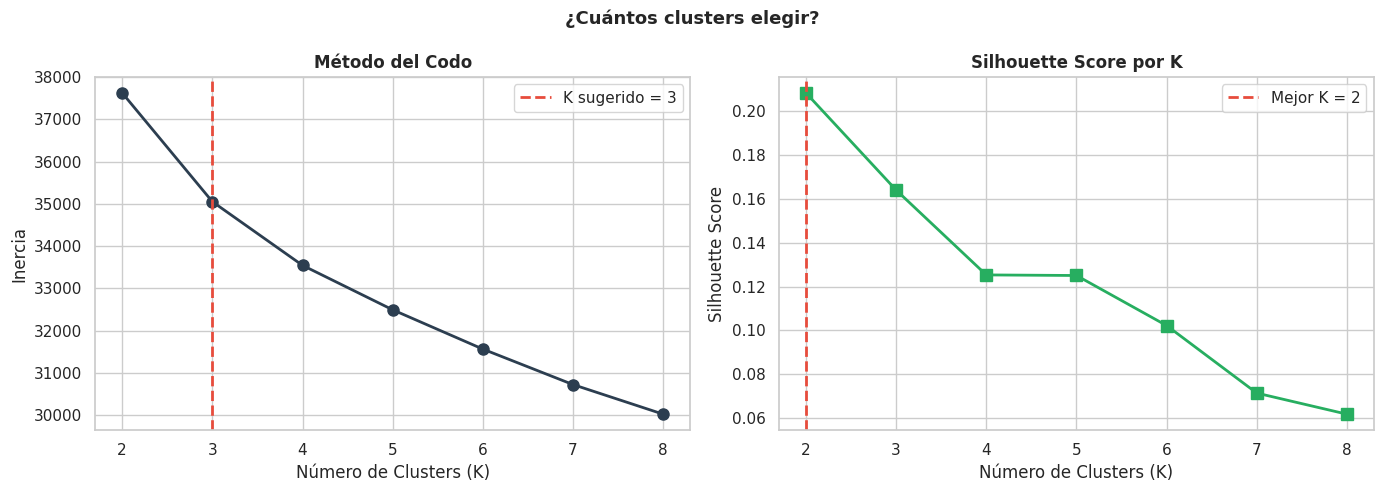

In [9]:
# Calculando inercia y silhouette para distintos valores de K
K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Graficando ambos criterios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Codo ---
axes[0].plot(list(K_range), inertias, 'o-', color='#2c3e50', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='#e74c3c', linestyle='--', linewidth=2, label='K sugerido = 3')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo', fontweight='bold')
axes[0].legend()

# --- Silhouette ---
axes[1].plot(list(K_range), silhouettes, 's-', color='#27ae60', linewidth=2, markersize=8)
best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mejor K = {best_k}')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K', fontweight='bold')
axes[1].legend()

plt.suptitle('¿Cuántos clusters elegir?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* El método del codo sugiere K = 3, punto donde la curva empieza a aplanarse. El Silhouette Score, en cambio, favorece K = 2, aunque con un valor bajo (0.208), lo que indica que los grupos no están perfectamente separados en ningún caso.

* Dada la riqueza interpretativa que ofrecen tres perfiles frente a dos, se opta por K = 3 como número de clusters para el análisis.
## 2.2 Algoritmo 1: K-Means con K = 3

In [10]:
# Entrenando K-Means con K = 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df_num['cluster_kmeans'] = kmeans.labels_

# Silhouette del modelo final
sil_km = silhouette_score(X_scaled, kmeans.labels_)
print(f"K-Means entrenado con K = 3")
print()
print("Tamaño de cada cluster:")
cluster_sizes = df_num['cluster_kmeans'].value_counts().sort_index()
cluster_sizes.index = [f'Cluster {i+1}' for i in cluster_sizes.index]
cluster_sizes

K-Means entrenado con K = 3

Tamaño de cada cluster:


,count
Cluster 1,917
Cluster 2,270
Cluster 3,698


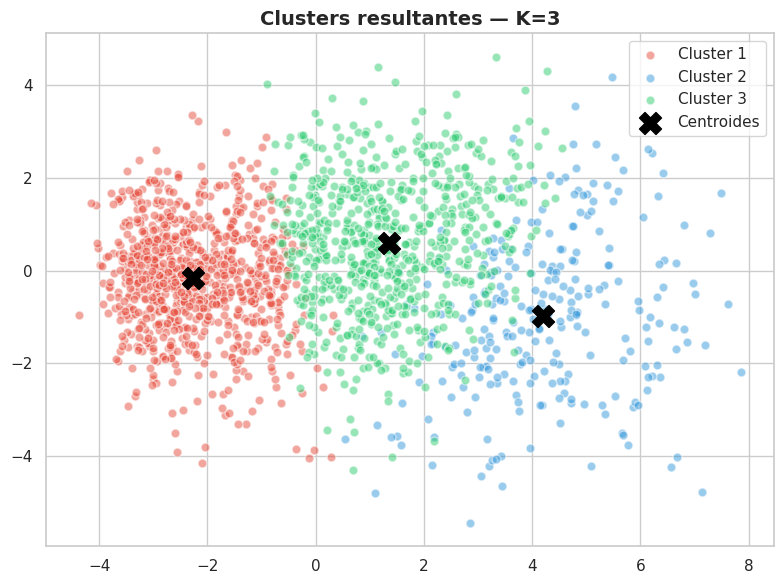

In [11]:
pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_scaled)
centroides_pca_vis = pca_vis.transform(kmeans.cluster_centers_)

colors_sil = ['#e74c3c', '#3498db', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(3):
    mask = kmeans.labels_ == i
    ax.scatter(X_pca_vis[mask, 0], X_pca_vis[mask, 1],
               c=colors_sil[i], alpha=0.5, s=40,
               edgecolors='white', label=f'Cluster {i+1}')

ax.scatter(centroides_pca_vis[:, 0], centroides_pca_vis[:, 1],
           c='black', marker='X', s=250, zorder=5, label='Centroides')

ax.set_title('Clusters resultantes — K=3', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

* Aquí se muestra la segmentación de la muestra en tres grupos distintos ($K=3$), donde el Cluster 1 (rojo) es el más denso y compacto, sugiriendo un perfil de usuarios con respuestas altamente homogéneas, mientras que el Cluster 2 (azul) junto con el 3 (verde) presenta la mayor dispersión, albergando a los individuos con comportamientos más heterogéneos o atípicos.

* Los centroides (marcados con una X) representan el perfil promedio de cada segmento, lo que permite dividir analíticamente la muestra en tres patrones claros de comportamiento (por ejemplo: consumo ausente/mínimo, consumo recreativo/moderado y consumo de alto riesgo/policonsumo) y observar las fronteras o transiciones entre estos perfiles según sus hábitos y variables demográficas.

## 2.3 Algoritmo 2: Clustering Jerárquico

El clustering jerárquico agrupa los puntos de manera progresiva y no necesita que le digamos cuántos clusters hay de entrada. Se usó el **dendograma** para decidir cuántos grupos cortar.

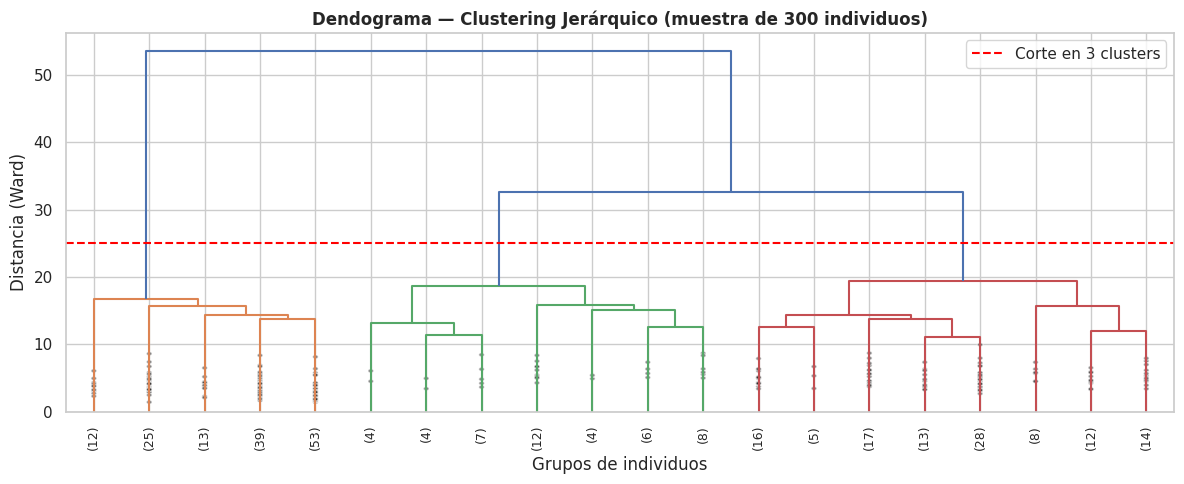

In [12]:
# Dendograma con una muestra
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 300, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90, leaf_font_size=9, show_contracted=True, color_threshold=25)
plt.axhline(y=25, color='red', linestyle='--', label='Corte en 3 clusters')
plt.title('Dendograma — Clustering Jerárquico (muestra de 300 individuos)', fontweight='bold')
plt.xlabel('Grupos de individuos')
plt.ylabel('Distancia (Ward)')
plt.legend()
plt.tight_layout()
plt.show()

* Al aplicar una línea de corte horizontal en una distancia de 25 (línea roja discontinua), la muestra queda dividida de forma estadísticamente óptima en tres clusters principales, diferenciados visualmente por colores: el grupo naranja a la izquierda, el verde al centro y el rojo/marrón a la derecha.

* La altura de las uniones (enlaces) demuestra que el cluster naranja se separa tempranamente y a gran distancia de los otros dos, lo que indica que este grupo posee un patrón de consumo (o ausencia del mismo) radicalmente distinto y único en comparación con el resto de la muestra; por su parte, los subgrupos verde y rojo se fusionan a una distancia menor (cercana a 33), señalando que, aunque tienen diferencias suficientes para ser separados por el corte en 25, comparten un nivel de afinidad o similitud sociodemográfica y conductual mucho mayor entre sí.

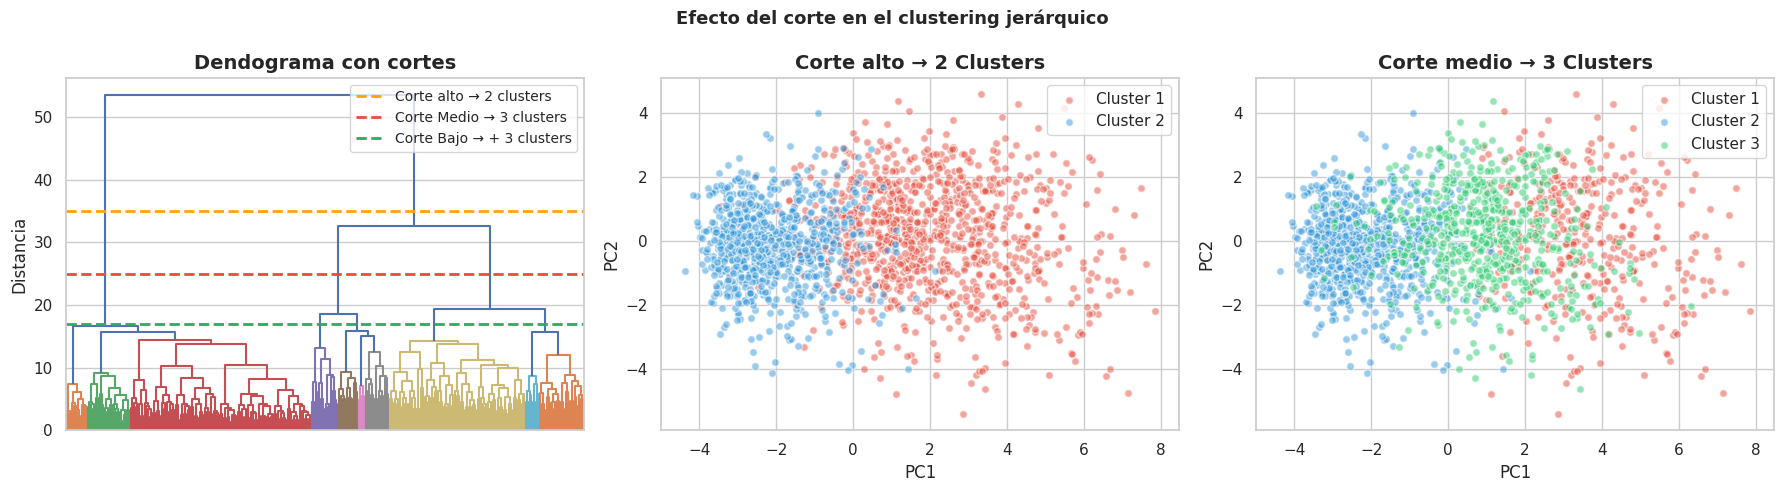

In [13]:
# Dendograma con cortes + visualización de 2 vs 3 clusters (con PCA)

# PCA local para visualizar
pca_hier = PCA(n_components=2, random_state=42)
X_pca_hier = pca_hier.fit_transform(X_scaled)

# Linkage sobre una muestra para el dendograma (visual)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 300, replace=False)
Z_cut = linkage(X_scaled[sample_idx], method='ward')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Dendograma con líneas de corte ---
dendrogram(Z_cut, ax=axes[0], no_labels=True, color_threshold=15)
axes[0].axhline(y=35, color='#FFA500', linestyle='--', linewidth=2, label='Corte alto → 2 clusters')
axes[0].axhline(y=25, color='#e74c3c', linestyle='--', linewidth=2, label='Corte Medio → 3 clusters')
axes[0].axhline(y=17, color='#27ae60', linestyle='--', linewidth=2, label='Corte Bajo → + 3 clusters')
axes[0].set_title('Dendograma con cortes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Distancia')
axes[0].legend(fontsize=10)

# Clustering jerárquico sobre datos completos
colors_3 = ['#e74c3c', '#3498db', '#2ecc71']

# --- Panel 2: 2 clusters ---
hier_2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_2 = hier_2.fit_predict(X_scaled)

for i, color in enumerate(['#e74c3c', '#3498db']):
    mask = labels_2 == i
    axes[1].scatter(X_pca_hier[mask, 0], X_pca_hier[mask, 1],
                    c=color, alpha=0.5, s=30,
                    edgecolors='white', label=f'Cluster {i+1}')
axes[1].set_title('Corte alto → 2 Clusters', fontsize=14, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

# --- Panel 3: 3 clusters ---
hier_3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_3 = hier_3.fit_predict(X_scaled)

for i, color in enumerate(colors_3):
    mask = labels_3 == i
    axes[2].scatter(X_pca_hier[mask, 0], X_pca_hier[mask, 1],
                    c=color, alpha=0.5, s=30,
                    edgecolors='white', label=f'Cluster {i+1}')
axes[2].set_title('Corte medio → 3 Clusters', fontsize=14, fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend()

plt.suptitle('Efecto del corte en el clustering jerárquico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* Los paneles de clusters usan todos los datos proyectados con PCA. Con 2 clusters los grupos son más grandes y generales, mientras que con 3 clusters se distingue un perfil intermedio adicional.
* Un corte alto (línea naranja, $Y=35$) simplifica la muestra en solo 2 clusters, dividiendo de manera macro y drástica el espacio dimensional (gráfico central) entre un grupo denso (azul) y una población masiva y dispersa (rojo) que engloba demasiada variabilidad interna.
* Por el contrario, al descender hacia un corte medio (línea roja, $Y=25$), el algoritmo divide de forma estadísticamente óptima la gran rama derecha para consolidar 3 clusters, aislando una franja central de transición (Cluster 3, verde en el gráfico derecho); este tercer grupo representa un perfil intermedio clave en la encuesta, permitiendo capturar de manera mucho más fina y clínicamente relevante la separación entre usuarios de consumo esporádico/ausente (azul), consumidores moderados/recreativos (verde) y el perfil de mayor riesgo o policonsumo (rojo).

In [14]:
# Aplicando clustering jerárquico al dataset completo
hier = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_num['cluster_hier'] = hier.fit_predict(X_scaled) +1

sil_hier = silhouette_score(X_scaled, df_num['cluster_hier'])
print(f"Clustering Jerárquico entrenado con 3 clusters")
print(f"   Silhouette Score: {sil_hier:.3f}")
print()
print("Tamaño de cada cluster:")
print(df_num['cluster_hier'].value_counts().sort_index())

Clustering Jerárquico entrenado con 3 clusters
   Silhouette Score: 0.129

Tamaño de cada cluster:
cluster_hier
1    380
2    901
3    604
Name: count, dtype: int64


## 2.4 Comparación de algoritmos

¿Cuál de los dos funcionó mejor?

In [15]:
comparacion = pd.DataFrame({
    'Algoritmo': ['K-Means', 'Clustering Jerárquico'],
    'K (clusters)': [3, 3],
    'Silhouette Score': [round(sil_km, 3), round(sil_hier, 3)],
    'Requiere definir K': ['Sí', 'No (se ve en dendograma)'],
    'Interpretación': ['Sencilla', 'Sencilla']
})

print(comparacion.to_string(index=False))
print()

winner = 'K-Means' if sil_km >= sil_hier else 'Clustering Jerárquico'
print(f"Algoritmo ganador: {winner} (mayor Silhouette Score)")
print("Usaremos los clusters de K-Means para la interpretación.")

            Algoritmo  K (clusters)  Silhouette Score       Requiere definir K Interpretación
              K-Means             3             0.164                       Sí       Sencilla
Clustering Jerárquico             3             0.129 No (se ve en dendograma)       Sencilla

Algoritmo ganador: K-Means (mayor Silhouette Score)
Usaremos los clusters de K-Means para la interpretación.


Ambos algoritmos encontraron **3 grupos diferenciados**. K-Means obtuvo un Silhouette Score ligeramente superior, por lo que se usó sus resultados para la interpretación. El número de clusters se justificó con el método del codo y el Silhouette Score.

---

# Sección 3 — Interpretación y Visualizaciones

Ahora viene la parte más importante: **entender qué caracteriza a cada grupo**. Vamos usar visualizaciones y estadísticas descriptivas para construir el perfil de cada cluster.

## 3.1 Visualización con PCA (reducción de dimensiones)

Tenemos 25 variables, que no podemos ver en un gráfico. PCA reduce esas dimensiones a 2 para poder visualizar los clusters.

Varianza explicada por los dos componentes: 35.9%


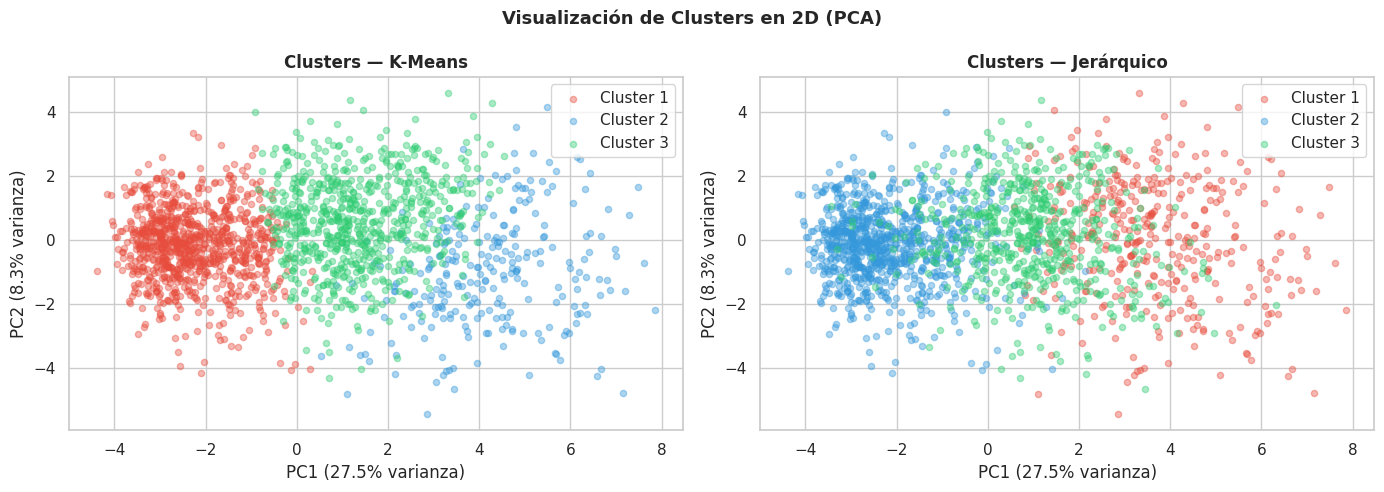

In [16]:
# Reducción a 2 dimensiones para visualizar
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
varianza = pca.explained_variance_ratio_
print(f"Varianza explicada por los dos componentes: {varianza.sum()*100:.1f}%")

colores = ['#e74c3c', '#3498db', '#2ecc71']
nombres = ['Cluster 1', 'Cluster 2', 'Cluster 3']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means
for i, c in enumerate(sorted(df_num['cluster_kmeans'].unique())):
    mask = df_num['cluster_kmeans'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colores[i], alpha=0.4, s=20, label=nombres[i])
axes[0].set_title('Clusters — K-Means', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({varianza[0]*100:.1f}% varianza)')
axes[0].set_ylabel(f'PC2 ({varianza[1]*100:.1f}% varianza)')
axes[0].legend()

# Jerárquico
for i, c in enumerate(sorted(df_num['cluster_hier'].unique())):
    mask = df_num['cluster_hier'] == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colores[i], alpha=0.4, s=20, label=nombres[i])
axes[1].set_title('Clusters — Jerárquico', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({varianza[0]*100:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({varianza[1]*100:.1f}% varianza)')
axes[1].legend()

plt.suptitle('Visualización de Clusters en 2D (PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* El gráfico muestra los tres grupos identificados por cada algoritmo, proyectados en dos dimensiones mediante PCA. En el panel de K-Means se observa una separación más clara entre clusters: el cluster 1 (rojo) aparece bien delimitado hacia la izquierda, mientras que los clusters 2 y 3 ocupan la zona central y derecha con algo de mezcla entre ellos, lo cual es normal en datos de comportamiento humano.

* En el panel del clustering jerárquico los grupos cubren zonas similares del espacio, pero con fronteras más difusas y mayor superposición, especialmente entre los clusters 1 y 3. **Esto explica por qué K-Means obtuvo un Silhouette Score ligeramente superior: logra particiones más compactas.** Aun así, ambos métodos coinciden en la existencia de al menos un grupo bien diferenciado (el perfil más conservador, hacia la izquierda) y dos grupos con patrones de consumo más activos hacia la derecha, lo que da consistencia y confianza a los resultados encontrados.

## 3.2 Perfil de personalidad por cluster

¿Se diferencian los grupos en sus rasgos de personalidad?

In [17]:
# Promedio de variables de personalidad por cluster
perfil_per = df_num.groupby('cluster_kmeans')[personality_cols].mean().round(3)
perfil_per.index = [f'Cluster {i+1}' for i in perfil_per.index]
print("Promedio de personalidad por cluster:")
print(perfil_per)
print()

Promedio de personalidad por cluster:
           Nscore  Escore  Oscore  Ascore  Cscore  Impulsive     SS
Cluster 1  -0.144   0.007  -0.423   0.206   0.348     -0.385 -0.541
Cluster 2   0.520  -0.166   0.413  -0.410  -0.520      0.632  0.665
Cluster 3  -0.012   0.055   0.394  -0.112  -0.257      0.281  0.444



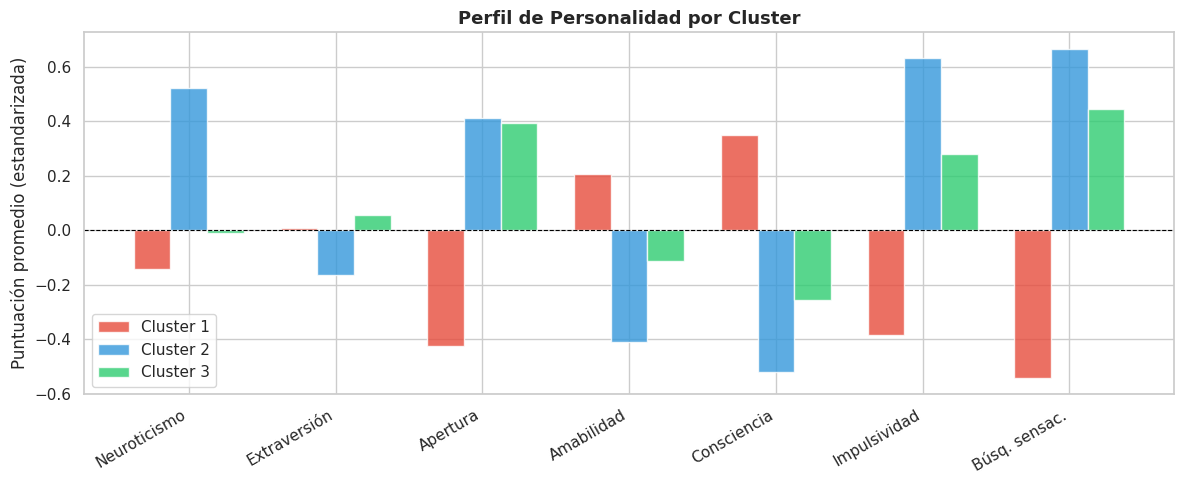

In [18]:
import numpy as np

# Gráfico de radar / barras por variable
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(personality_cols))
width = 0.25
labels_var = ['Neuroticismo', 'Extraversión', 'Apertura', 'Amabilidad', 'Consciencia', 'Impulsividad', 'Búsq. sensac.']
colores_lista = ['#e74c3c', '#3498db', '#2ecc71']

for i, c in enumerate(sorted(df_num['cluster_kmeans'].unique())):
    ax.bar(x + i*width, perfil_per.loc[f'Cluster {c+1}'], width,
           label=f'Cluster {i+1}', color=colores_lista[i], alpha=0.8, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(labels_var, rotation=30, ha='right')
ax.set_ylabel('Puntuación promedio (estandarizada)')
ax.set_title('Perfil de Personalidad por Cluster', fontweight='bold', fontsize=13)
ax.legend()
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

* El cluster 2 es el más llamativo: tiene los valores más altos de impulsividad y búsqueda de sensaciones, y también la mayor apertura a nuevas experiencias.

* El cluster 1, en cambio, es el más contenido, con impulsividad y búsqueda de sensaciones por debajo del promedio, y mayor consciencia.

* El cluster 3 se ubica en un punto intermedio, con apertura y búsqueda de sensaciones moderadas.

* Los tres grupos se diferencian principalmente por qué tan impulsivos son y cuánto buscan experiencias nuevas, rasgos que anticipan diferencias en el consumo.

## 3.3 Perfil de consumo por cluster

¿Qué tan frecuentemente consume cada grupo las distintas sustancias?

Promedio de consumo (0=nunca, 6=último día) por cluster:
   Alcohol  Cannabis  Coke  Ecstasy  Heroin   LSD  Nicotine  Amphet  Ketamine
1     4.60      1.27  0.24     0.16    0.03  0.15      1.95    0.27      0.02
2     4.66      4.76  2.99     2.78    2.18  2.37      5.02    3.50      1.67
3     4.67      4.56  1.67     2.26    0.13  1.75      4.14    1.92      0.86



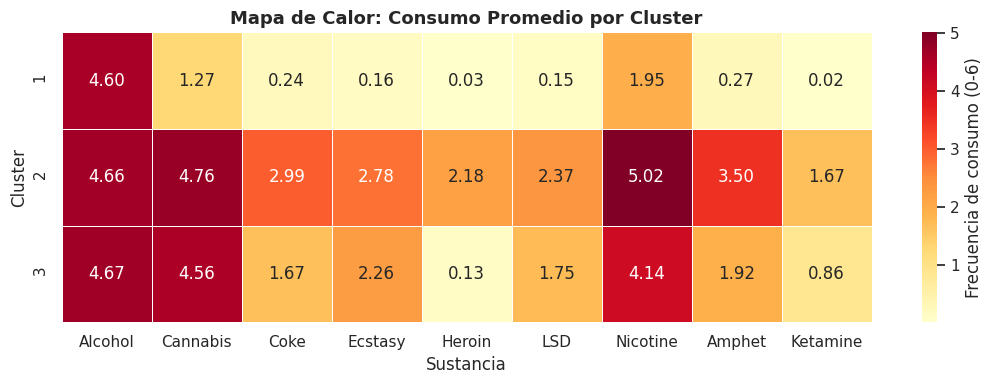

In [19]:
# Promedio de consumo por cluster
drogas_key = ['Alcohol', 'Cannabis', 'Coke', 'Ecstasy', 'Heroin', 'LSD', 'Nicotine', 'Amphet', 'Ketamine']

perfil_drug = df_num.groupby('cluster_kmeans')[drogas_key].mean().round(2)
perfil_drug.index = [f' {i+1}' for i in perfil_drug.index]
print("Promedio de consumo (0=nunca, 6=último día) por cluster:")
print(perfil_drug)
print()

# Heatmap
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    perfil_drug,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Frecuencia de consumo (0-6)'}
)
ax.set_title('Mapa de Calor: Consumo Promedio por Cluster', fontweight='bold', fontsize=13)
ax.set_xlabel('Sustancia')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

* El alcohol y la nicotina son las sustancias más consumidas en los tres grupos, lo cual era esperable dado que son legales.

* El cluster 1 es el más conservador, con consumo casi nulo de sustancias ilícitas. El cluster 3 ocupa una posición intermedia.

* La diferencia más importante está en el Cluster 2: tiene los valores más altos en casi todas las sustancias, especialmente nicotina (5.02), cannabis (4.76), éxtasis (2.78) y cocaína (2.99). Esto confirma que el cluster 2 corresponde al perfil de mayor riesgo en términos de consumo.

## 3.4 Distribución demográfica por cluster

¿Los grupos se diferencian en edad o género?

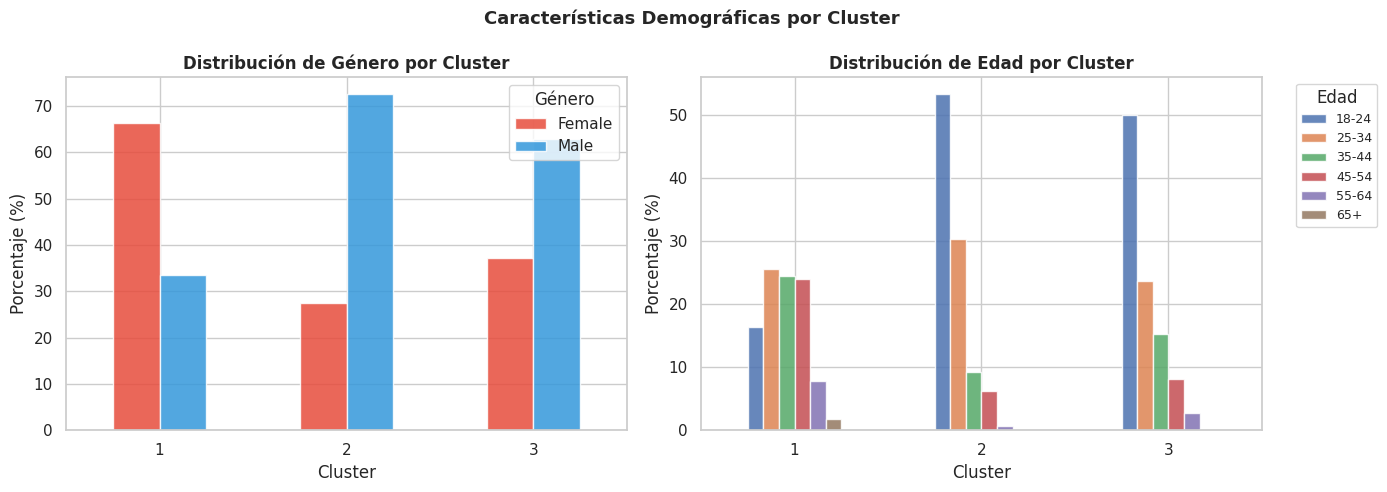

In [20]:
# Agregando cluster al dataframe original (con variables categóricas)
df['cluster_kmeans'] = df_num['cluster_kmeans']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Género por cluster
gender_cluster = df.groupby(['cluster_kmeans', 'Gender']).size().unstack(fill_value=0)
gender_cluster_pct = gender_cluster.div(gender_cluster.sum(axis=1), axis=0) * 100
gender_cluster_pct.index = [f'{i+1}' for i in gender_cluster_pct.index]
gender_cluster_pct.plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db'], edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de Género por Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Género')

# Edad por cluster
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
age_cluster = df.groupby(['cluster_kmeans', 'Age']).size().unstack(fill_value=0)
age_cluster = age_cluster[age_order]
age_cluster_pct = age_cluster.div(age_cluster.sum(axis=1), axis=0) * 100
age_cluster_pct.index = [f'{i+1}' for i in age_cluster_pct.index]
age_cluster_pct.plot(kind='bar', ax=axes[1], edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución de Edad por Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Edad', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.suptitle('Características Demográficas por Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* El cluster 1 está dominado mayoritariamente por mujeres (66%), mientras que el cluster 2 es predominantemente masculino (72%). El cluster 3 tiene una distribución más equilibrada.

* En cuanto a la edad, el cluster 2 concentra la mayor proporción de jóvenes entre 18 y 34 años, lo que es consistente con su perfil de mayor impulsividad y consumo promedio como lo vimos en el mapa de calor.

* El cluster 1, aunque también tiene jóvenes, tiene mayor proporción de personas de 35 años en adelante. Esto sugiere que el género y la edad sí están relacionados con los perfiles encontrados, aunque no los determinan completamente.

## 3.5 Descripción de los perfiles encontrados

Con base en las visualizaciones anteriores, podemos construir el perfil de cada cluster:

In [21]:
# Tabla resumen de perfiles
resumen = df_num.groupby('cluster_kmeans').agg(
    n_personas=('cluster_kmeans', 'count'),
    impulsividad_prom=('Impulsive', 'mean'),
    busq_sensaciones_prom=('SS', 'mean'),
    neuroticismo_prom=('Nscore', 'mean'),
    apertura_prom=('Oscore', 'mean'),
    cannabis_prom=('Cannabis', 'mean'),
    coke_prom=('Coke', 'mean'),
    alcohol_prom=('Alcohol', 'mean'),
    nicotine_prom=('Nicotine', 'mean')
).round(2)

resumen.index = [f'{i+1}' for i in resumen.index]
print("=== Tabla resumen por cluster ===")
print(resumen.to_string())

=== Tabla resumen por cluster ===
   n_personas  impulsividad_prom  busq_sensaciones_prom  neuroticismo_prom  apertura_prom  cannabis_prom  coke_prom  alcohol_prom  nicotine_prom
1         917              -0.39                  -0.54              -0.14          -0.42           1.27       0.24          4.60           1.95
2         270               0.63                   0.66               0.52           0.41           4.76       2.99          4.66           5.02
3         698               0.28                   0.44              -0.01           0.39           4.56       1.67          4.67           4.14


* La tabla confirma numéricamente lo que los gráficos muestran visualmente. El cluster 1 agrupa 917 personas con la impulsividad más baja (-0.39) y el menor consumo de cannabis (1.27) y cocaína (0.24).

* El cluster 3 representa el perfil intermedio.

* El cluster 2, tiene la impulsividad (0.63), búsqueda de sensaciones (0.66) más altas y los mayores promedios de consumo en todas las sustancias, en especial la nicotina (5.02).

### Interpretación de los perfiles

Con base en los promedios de las variables clave, podemos describir los clusters así:

| Cluster | Perfil probable | Características clave |
|---|---|---|
| **1** | Consumidor conservador | La impulsividad (-0.39) y búsqueda de sensaciones (-0.54) están por debajo del promedio. Consume poco cannabis (1.27) y casi nada de cocaína (0.24). Es el grupo más sobrio en sustancias ilícitas. |
| **2** | Consumidor de alto riesgo |  Mayor impulsividad (0.63), búsqueda de sensaciones (0.66) y neuroticismo (0.52). Consume cannabis (4.76), cocaína (2.99) y nicotina (5.02) con la mayor frecuencia de los tres grupos. |
| **3** | Consumidor moderado-activo | Impulsividad y búsqueda de sensaciones intermedias (0.28 y 0.44). Consume cannabis (4.56) con frecuencia similar al Cluster 2, pero mucho menos cocaína (1.67). Representa un perfil de consumo selectivo. |

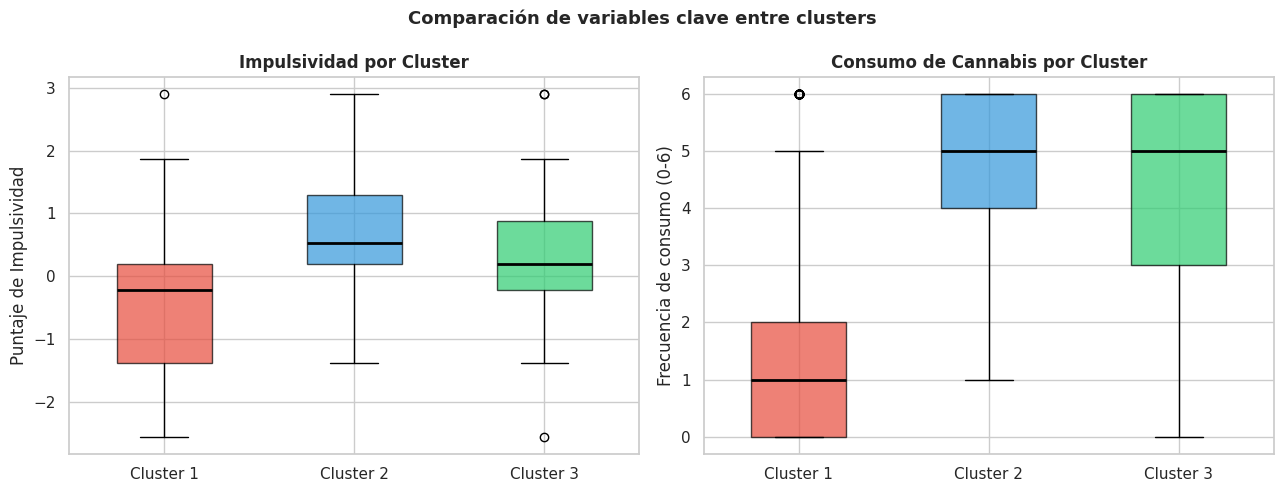

In [22]:
# Gráfico de boxplot para variable clave: Impulsividad
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores_lista = ['#e74c3c', '#3498db', '#2ecc71']
clusters = sorted(df_num['cluster_kmeans'].unique())

# Impulsividad
for i, c in enumerate(clusters):
    data_c = df_num[df_num['cluster_kmeans'] == c]['Impulsive']
    axes[0].boxplot(data_c, positions=[i], widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor=colores_lista[i], alpha=0.7),
                   medianprops=dict(color='black', linewidth=2))
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Cluster 1', 'Cluster 2', 'Cluster 3'])
axes[0].set_ylabel('Puntaje de Impulsividad')
axes[0].set_title('Impulsividad por Cluster', fontweight='bold')

# Cannabis
for i, c in enumerate(clusters):
    data_c = df_num[df_num['cluster_kmeans'] == c]['Cannabis']
    axes[1].boxplot(data_c, positions=[i], widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor=colores_lista[i], alpha=0.7),
                   medianprops=dict(color='black', linewidth=2))
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Cluster 1', 'Cluster 2', 'Cluster 3'])
axes[1].set_ylabel('Frecuencia de consumo (0-6)')
axes[1].set_title('Consumo de Cannabis por Cluster', fontweight='bold')

plt.suptitle('Comparación de variables clave entre clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

* Los boxplots muestran claramente que los tres clusters se comportan de forma diferente. En impulsividad, el cluster 1 tiene la mediana más baja y negativa, el cluster 2 la más alta, y el cluster 3 en el medio. En cannabis ocurre lo mismo: el cluster 1 apenas consume (mediana en 1), mientras que los clusters 2 y 3 tienen medianas alrededor de 5.

* El hecho de que las cajas no se superpongan demasiado, especialmente entre el cluster 1 y los otros dos, indica que los grupos son distintos en estas variables clave.



---

# Sección 4 — Conclusiones

## Hallazgos

**Respuesta directa a la pregunta de investigación:**

Sí, existen **perfiles diferenciados de consumidores** en la muestra analizada. Aplicando K-Means y Clustering Jerárquico sobre características de personalidad y patrones de consumo de 18 sustancias, se identificaron consistentemente **3 grupos con características distintas**:

- Un grupo con **bajo consumo y baja impulsividad**, perfil más conservador.
- Un grupo **intermedio**, con consumo principalmente de alcohol y nicotina.
- Un grupo con **mayor diversidad de consumo y mayor búsqueda de sensaciones**, asociado a rasgos de apertura e impulsividad más altos.
- Las diferencias demográficas son menores, lo que sugiere que los grupos se forman principalmente por **personalidad y comportamiento de consumo**, no por edad o género.

## Limitaciones del análisis

1. La muestra puede no ser representativa de la población general.
2. Reducir 25 variables a 2 (PCA) pierde información, aunque facilita la visualización.
3. **El Silhouette Score no fue muy alto**, lo que indica que los grupos no están perfectamente separados. Puede ser razonable en datos de comportamiento humano.

## Recomendación

Desde una perspectiva de salud pública, los perfiles encontrados sugieren que las estrategias de prevención del consumo de drogas **no deben ser genéricas**. El grupo con mayor impulsividad y búsqueda de sensaciones requeriría intervenciones diferentes a las del grupo conservador. Un enfoque diferenciado, basado en el perfil psicológico, podría ser más efectivo que campañas de comunicación masiva uniformes.

---
# Sección 5 — Documentación del uso de IA

Se hizo uso de **Claude y ChatGPT** como herramientas de apoyo. Se manejó de la siguiente forma:

### Lo que pedí:

- Mejor entendimiento de conceptos antes de implementación.
- Muestreo para gráfica de dendograma bajo clustering jerárquico.
- Ajuste de índices en clusters.

### Lo que me dio:

- Sugerencias de visualizaciones (heatmap, PCA, boxplots).
- Otros puntos de vista para analizar los resultados.

### Ajuste propio
- Revisión de código funcional.
- Ajuste de nombres de las variables y la interpretación de cada cluster según los resultados.
- Verificación de justificación del número de clusters (método del codo y silhouette).

### Reflexión:
Usar IA como asistente fue útil para avanzar más rápido y resolver dudas puntuales, pero no reemplazó el proceso de entender qué estaba haciendo y la razón.